# Penguin Species Classification
## Decision Tree and Random Forest Classifiers

This project classifies penguin species from physical measurements using two tree-based methods, building from a single Decision Tree baseline through to a full Random Forest ensemble. Both models are trained on the same Palmer Penguins dataset, making it straightforward to compare how ensemble aggregation improves on the variance and generalization limitations of a single tree.

A second dataset (UCI Banknote Authentication) is introduced in the Random Forest section to demonstrate GridSearchCV hyperparameter tuning and OOB scoring on a larger binary classification task.

### Dataset

The [Palmer Penguins dataset](https://allisonhorst.github.io/palmerpenguins/) contains 344 records across three species (Adelie, Chinstrap, Gentoo) collected from three islands in the Palmer Archipelago, Antarctica. Features include culmen length and depth, flipper length, body mass, island, and sex.

### Workflow

**Part 1:** EDA: missing value audit, distribution plots, pairplot by species

**Part 2:** Feature Engineering: one-hot encoding of categorical variables

**Part 3:** Decision Tree baseline: fit, evaluate, visualize, feature importances

**Part 4:** Decision Tree hyperparameter exploration: max_depth, max_leaf_nodes, criterion

**Part 5:** Random Forest baseline: ensemble of 10 trees, evaluation, feature importances

**Part 6:** Tree count sweep: identifying diminishing returns in ensemble size

**Part 7:** Banknote Authentication: GridSearchCV tuning, OOB scoring, error rate analysis

### Stack

Python, Pandas, NumPy, Matplotlib, Seaborn, scikit-learn

---
## Part 1: Setup and Exploratory Data Analysis

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report,
    ConfusionMatrixDisplay, accuracy_score
)

%matplotlib inline
sns.set_style('darkgrid')

In [ ]:
df = pd.read_csv("penguins_size.csv")

In [ ]:
df.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   culmen_length_mm   342 non-null    float64
 3   culmen_depth_mm    342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                334 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [ ]:
df.isna().sum()

species               0
island                0
culmen_length_mm      2
culmen_depth_mm       2
flipper_length_mm     2
body_mass_g           2
sex                  10
dtype: int64

10 records (2.9%) are missing values across culmen, flipper, body mass, and sex columns. Since these measurements are the core predictive features, rows with missing values are dropped rather than imputed to avoid introducing noise into a dataset of this size.

In [ ]:
# What percentage are we dropping?
100*(10/344)

2.9069767441860463

In [ ]:
df = df.dropna()
df = df[df['sex'] != '.']
print(f'Clean dataset: {df.shape[0]} records')

<class 'pandas.core.frame.DataFrame'>
Int64Index: 334 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            334 non-null    object 
 1   island             334 non-null    object 
 2   culmen_length_mm   334 non-null    float64
 3   culmen_depth_mm    334 non-null    float64
 4   flipper_length_mm  334 non-null    float64
 5   body_mass_g        334 non-null    float64
 6   sex                334 non-null    object 
dtypes: float64(4), object(3)
memory usage: 20.9+ KB


### Species, Island, and Sex Distribution

In [ ]:
df['island'].unique()

array(['Torgersen', 'Biscoe', 'Dream'], dtype=object)

In [ ]:
df['sex'].unique()

array(['MALE', 'FEMALE', '.'], dtype=object)

### Feature Space by Species

Pairplot and scatter plots reveal that species cluster clearly in several feature combinations, particularly culmen length vs. depth and flipper length vs. body mass. These separations suggest tree-based classifiers should achieve strong performance with relatively shallow splits.

<Axes: xlabel='culmen_length_mm', ylabel='culmen_depth_mm'>

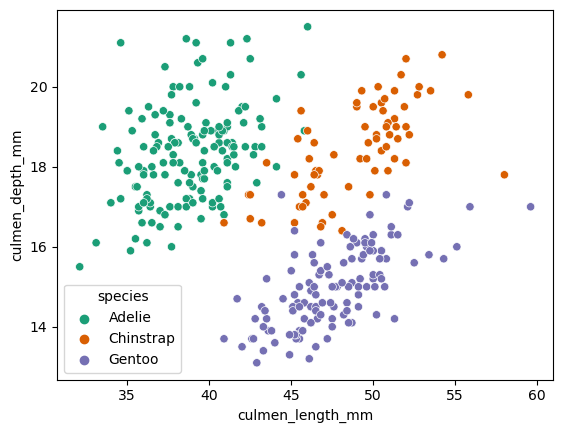

In [ ]:
sns.scatterplot(x='culmen_length_mm',y='culmen_depth_mm',data=df,hue='species',palette='Dark2')

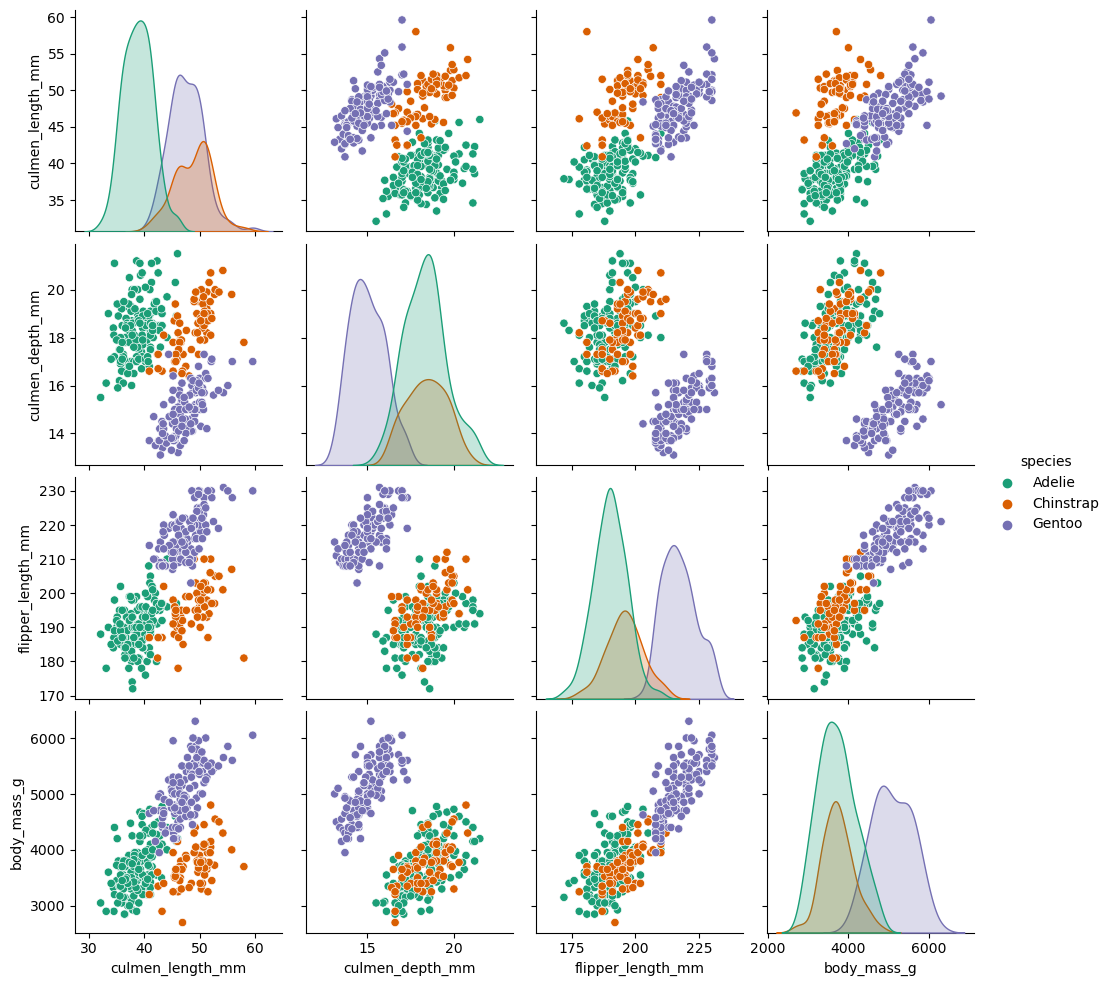

In [ ]:
sns.pairplot(df,hue='species',palette='Dark2')

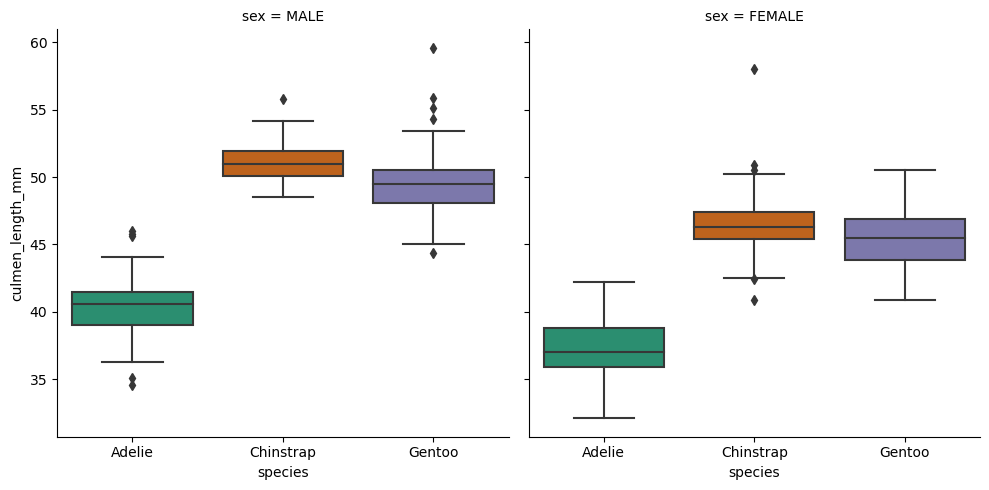

In [ ]:
sns.catplot(x='species',y='culmen_length_mm',data=df,kind='box',col='sex',palette='Dark2')

---
## Part 2: Feature Engineering

The `island` and `sex` columns are nominal categorical variables. One-hot encoding converts them to binary columns the models can split on directly. `drop_first=True` removes one dummy column per variable to avoid perfect multicollinearity.

In [ ]:
pd.get_dummies(df)

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,species_Adelie,species_Chinstrap,species_Gentoo,island_Biscoe,island_Dream,island_Torgersen,sex_FEMALE,sex_MALE
0,39.1,18.7,181.0,3750.0,1,0,0,0,0,1,0,1
1,39.5,17.4,186.0,3800.0,1,0,0,0,0,1,1,0
2,40.3,18.0,195.0,3250.0,1,0,0,0,0,1,1,0
4,36.7,19.3,193.0,3450.0,1,0,0,0,0,1,1,0
5,39.3,20.6,190.0,3650.0,1,0,0,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
338,47.2,13.7,214.0,4925.0,0,0,1,1,0,0,1,0
340,46.8,14.3,215.0,4850.0,0,0,1,1,0,0,1,0
341,50.4,15.7,222.0,5750.0,0,0,1,1,0,0,0,1
342,45.2,14.8,212.0,5200.0,0,0,1,1,0,0,1,0


In [ ]:
pd.get_dummies(df.drop('species',axis=1),drop_first=True)

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,island_Dream,island_Torgersen,sex_MALE
0,39.1,18.7,181.0,3750.0,0,1,1
1,39.5,17.4,186.0,3800.0,0,1,0
2,40.3,18.0,195.0,3250.0,0,1,0
4,36.7,19.3,193.0,3450.0,0,1,0
5,39.3,20.6,190.0,3650.0,0,1,1
...,...,...,...,...,...,...,...
338,47.2,13.7,214.0,4925.0,0,0,0
340,46.8,14.3,215.0,4850.0,0,0,0
341,50.4,15.7,222.0,5750.0,0,0,1
342,45.2,14.8,212.0,5200.0,0,0,0


### Train/Test Split

In [ ]:
X = pd.get_dummies(df.drop('species', axis=1), drop_first=True)
y = df['species']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Features: {list(X.columns)}')

---
## Part 3: Decision Tree Classifier

A single decision tree partitions the feature space through a sequence of binary splits, choosing at each node the feature and threshold that best reduces class impurity. Unlike ensemble methods, every prediction traces a path through explicit, interpretable rules that can be fully visualized.

An unconstrained tree grows until all leaves are pure, producing a complex model that fits training data exactly but often overfits. This serves as the performance ceiling before pruning is applied in Part 4.

In [ ]:
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

DecisionTreeClassifier()

In [ ]:
base_pred = model.predict(X_test)

print(classification_report(y_test, base_pred))

              precision    recall  f1-score   support

      Adelie       0.95      0.95      0.95        40
   Chinstrap       0.93      0.96      0.95        27
      Gentoo       1.00      0.97      0.98        33

    accuracy                           0.96       100
   macro avg       0.96      0.96      0.96       100
weighted avg       0.96      0.96      0.96       100



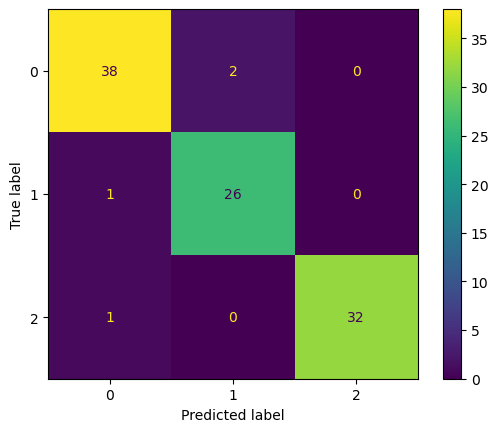

In [ ]:
ConfusionMatrixDisplay(
    confusion_matrix(y_test, base_pred),
    display_labels=model.classes_
).plot()
plt.title('Decision Tree (Unconstrained)')
plt.show()

### Feature Importances

The Gini-based feature importance score measures how much each feature reduces impurity across all splits. Higher scores indicate features the tree relied on most heavily.

In [ ]:
feat_imp = pd.DataFrame(
    index=X.columns,
    data=model.feature_importances_,
    columns=['Feature Importance']
).sort_values('Feature Importance', ascending=False)

feat_imp

,Feature Importance
culmen_length_mm,0.340359
culmen_depth_mm,0.045822
flipper_length_mm,0.575758
body_mass_g,0.000000
island_Dream,0.038061
island_Torgersen,0.000000
sex_MALE,0.000000


In [ ]:
feat_imp.plot(kind='barh', figsize=(8, 5))
plt.title('Feature Importances')
plt.tight_layout()

Body mass emerges as the most important single feature, consistent with the visible separation in the pairplot. Culmen length and flipper length follow closely.

<Axes: xlabel='species', ylabel='body_mass_g'>

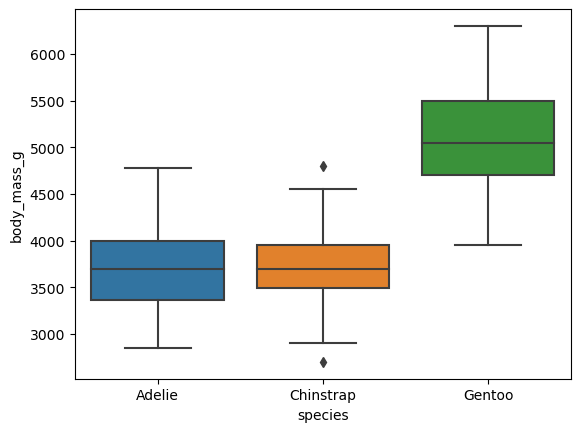

In [ ]:
sns.boxplot(x='species',y='body_mass_g',data=df)

### Tree Visualization

Rendering the full tree reveals the exact sequence of splits the model learned. Each node shows the feature and threshold used to split, the Gini impurity, sample count, and class distribution. Colored nodes indicate the majority class at that node.

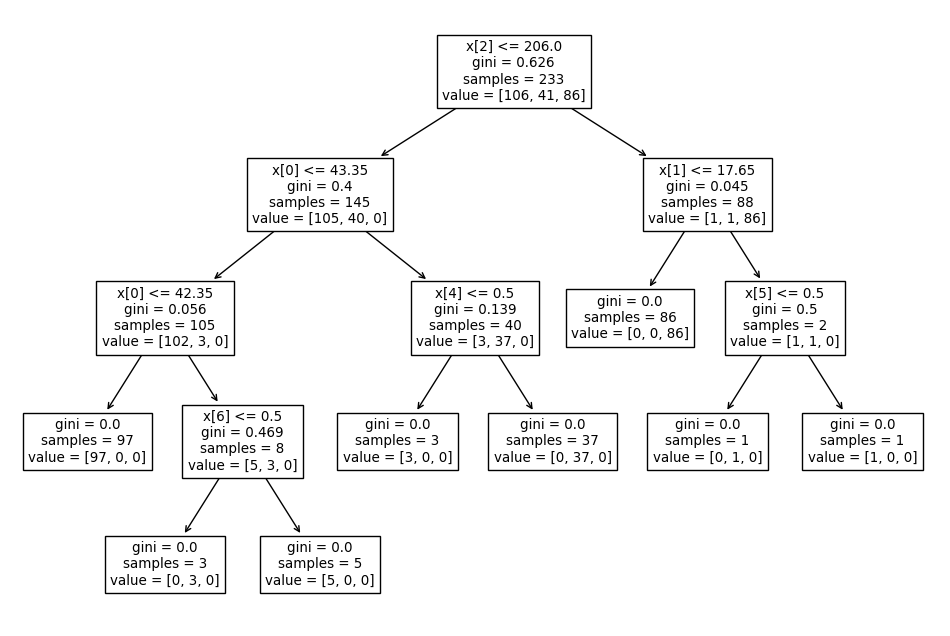

In [ ]:
plt.figure(figsize=(12,8))
plot_tree(model);

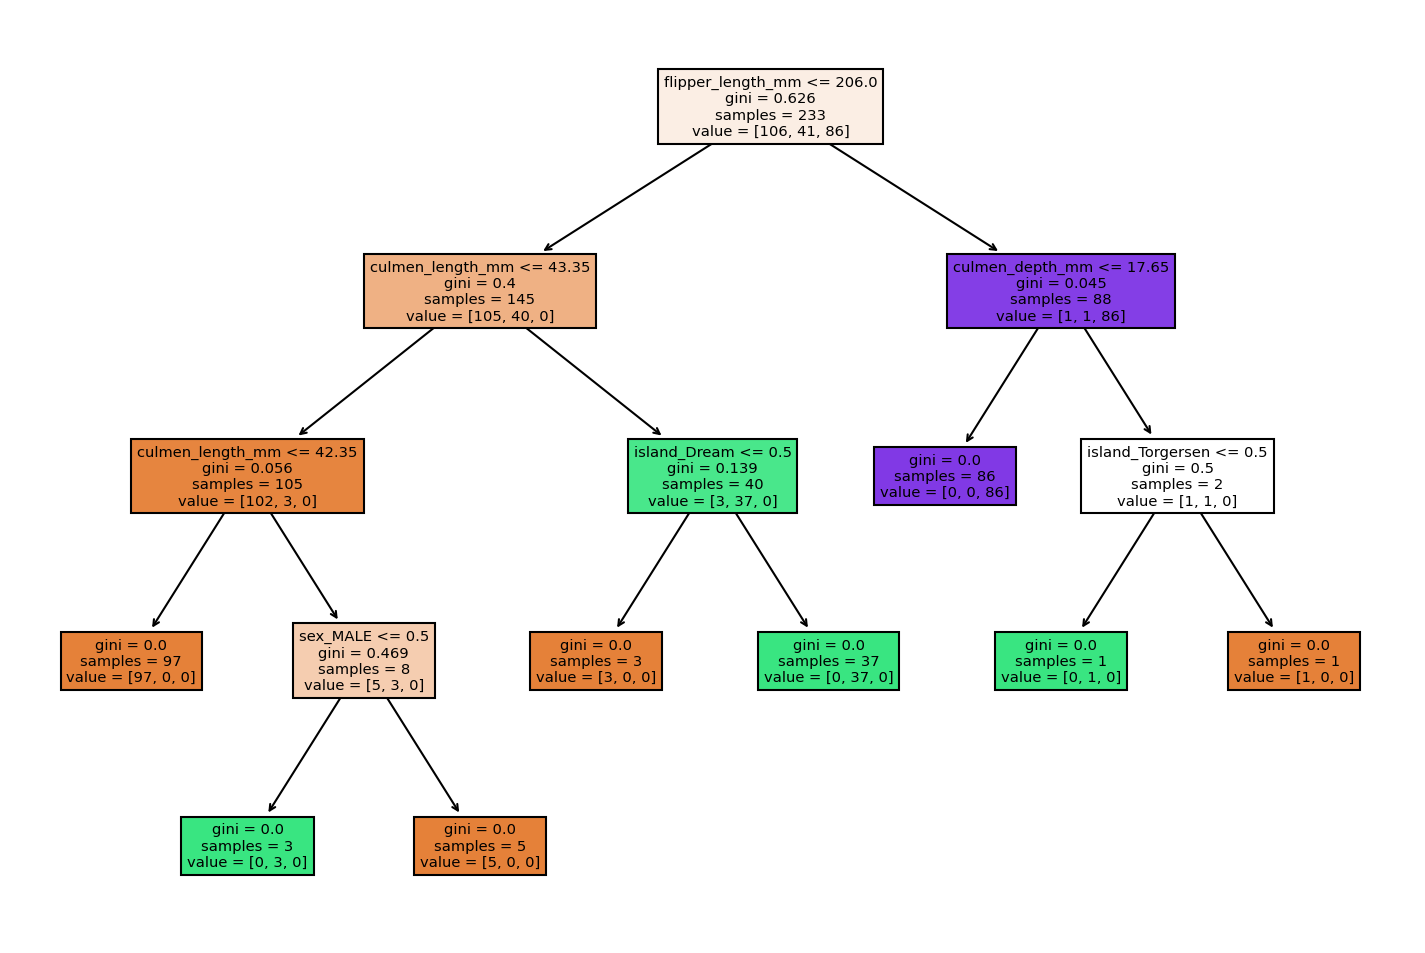

In [ ]:
plt.figure(figsize=(12,8),dpi=150)
plot_tree(model,filled=True,feature_names=X.columns);

---
## Part 4: Decision Tree Hyperparameter Exploration

An unconstrained tree will overfit. Three pruning parameters are explored to find a simpler model that generalizes better without sacrificing meaningful accuracy.

In [ ]:
def report_model(model):
    preds = model.predict(X_test)
    print(classification_report(y_test, preds))
    cm = confusion_matrix(y_test, preds)
    ConfusionMatrixDisplay(cm, display_labels=model.classes_).plot()
    plt.title(f'{model.__class__.__name__} — params: {model.get_params()}')
    plt.show()

### Max Depth

`max_depth` limits how many levels the tree can grow. Shallow trees are more interpretable and less prone to overfitting, but may underfit if set too low. Depth=2 forces the model to rely on the two most discriminative splits.

              precision    recall  f1-score   support

      Adelie       0.87      0.97      0.92        40
   Chinstrap       0.91      0.78      0.84        27
      Gentoo       1.00      0.97      0.98        33

    accuracy                           0.92       100
   macro avg       0.93      0.91      0.91       100
weighted avg       0.92      0.92      0.92       100





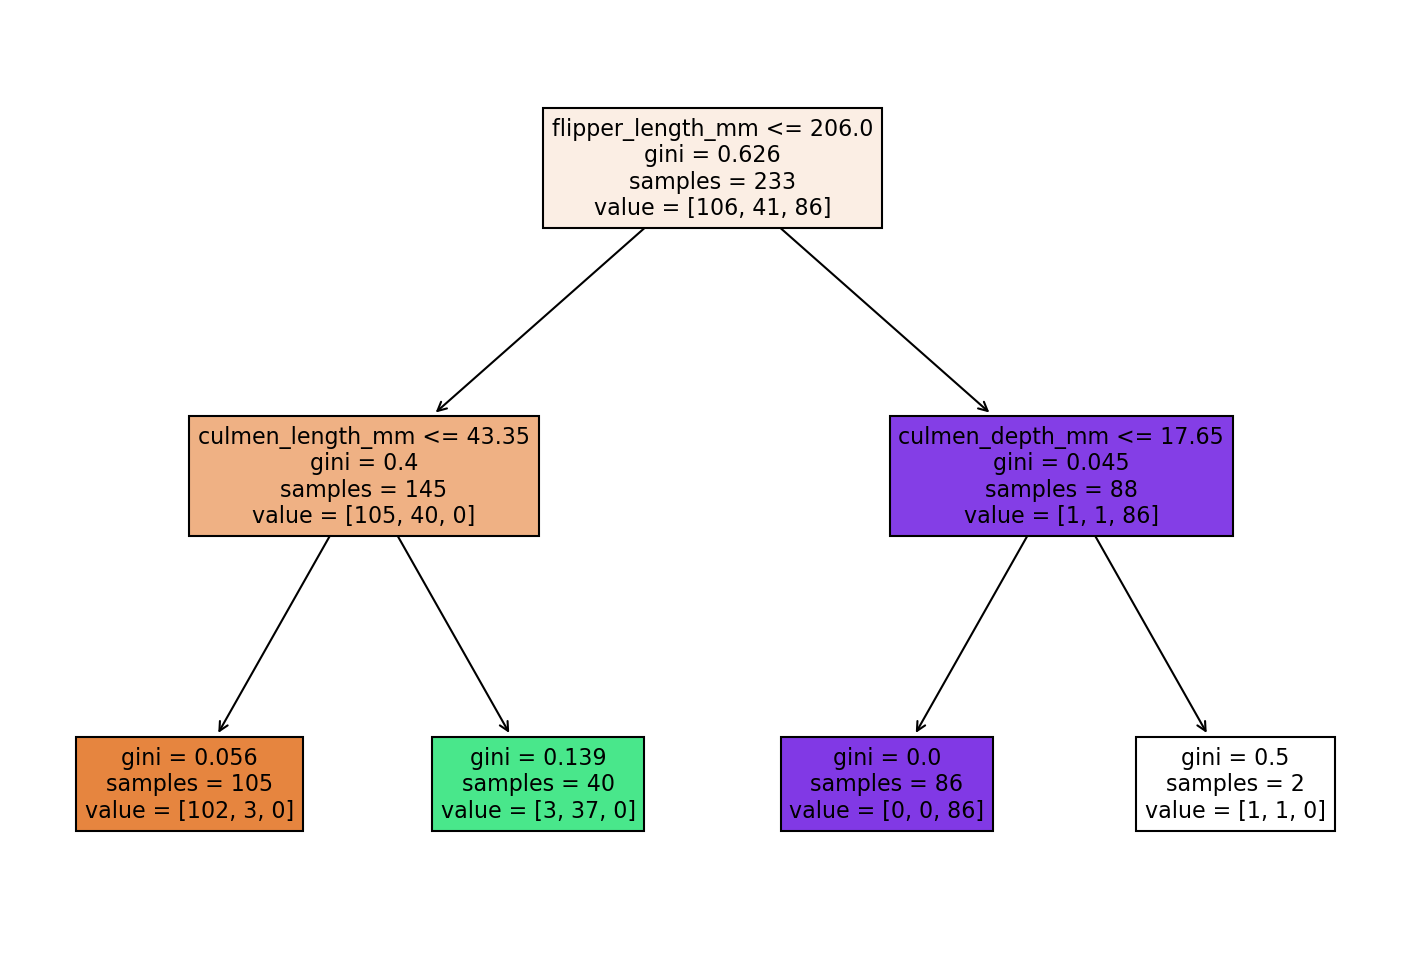

In [ ]:
pruned_tree = DecisionTreeClassifier(max_depth=2)
pruned_tree.fit(X_train, y_train)
report_model(pruned_tree)

### Max Leaf Nodes

`max_leaf_nodes` caps the number of terminal nodes while allowing variable depth. This is an alternative pruning approach that lets the tree grow deeper where it needs to while limiting total complexity.

              precision    recall  f1-score   support

      Adelie       0.95      0.95      0.95        40
   Chinstrap       0.91      0.78      0.84        27
      Gentoo       0.86      0.97      0.91        33

    accuracy                           0.91       100
   macro avg       0.91      0.90      0.90       100
weighted avg       0.91      0.91      0.91       100





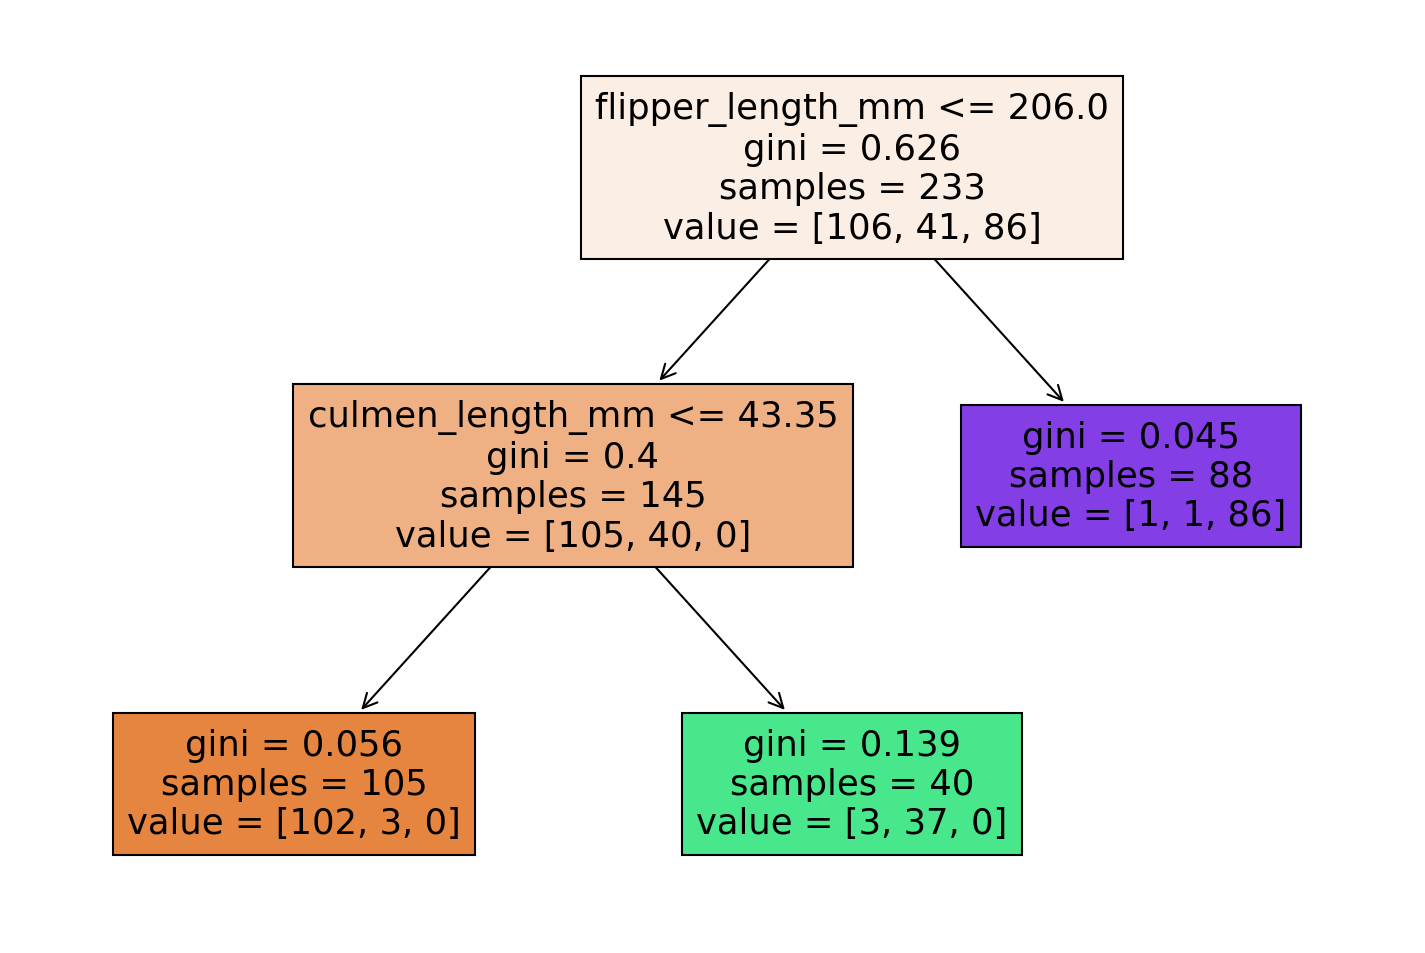

In [ ]:
leaf_tree = DecisionTreeClassifier(max_leaf_nodes=3)
leaf_tree.fit(X_train, y_train)
report_model(leaf_tree)

### Criterion: Gini vs. Entropy

The `criterion` parameter controls how split quality is measured. **Gini impurity** (default) measures the probability of incorrect classification. **Entropy** measures information gain. Both guide the same search for the best split and typically produce similar trees, though entropy can occasionally identify different optimal thresholds.

              precision    recall  f1-score   support

      Adelie       0.95      0.95      0.95        40
   Chinstrap       0.93      0.96      0.95        27
      Gentoo       1.00      0.97      0.98        33

    accuracy                           0.96       100
   macro avg       0.96      0.96      0.96       100
weighted avg       0.96      0.96      0.96       100





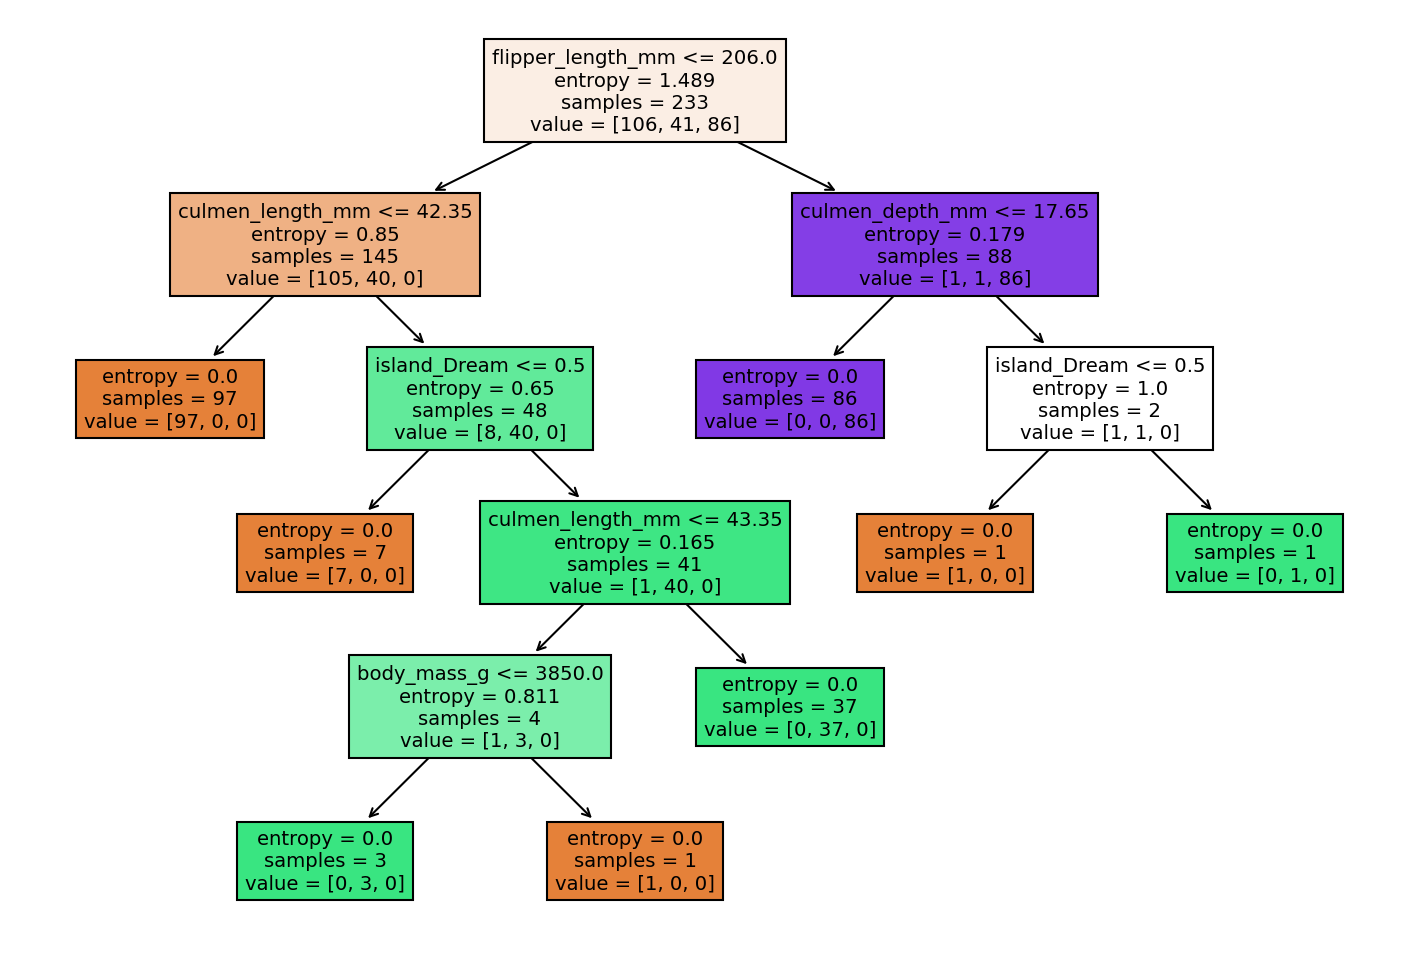

In [ ]:
entropy_tree = DecisionTreeClassifier(criterion='entropy')
entropy_tree.fit(X_train, y_train)
report_model(entropy_tree)

---
## Part 5: Random Forest Classifier

Random Forest addresses the core weakness of a single decision tree: high variance. By training many trees on bootstrapped data subsets with random feature subsets at each split, then aggregating predictions by majority vote, the ensemble reduces variance without increasing bias.

The same train/test split from Part 2 is reused, allowing direct comparison against the single decision tree results above.

In [ ]:
rf_model = RandomForestClassifier(n_estimators=10, max_features='sqrt', random_state=101)
rf_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=10, random_state=101)

In [ ]:
rf_preds = rf_model.predict(X_test)

print(f'Accuracy: {accuracy_score(y_test, rf_preds):.4f}')
print()
print(classification_report(y_test, rf_preds))

In [ ]:
ConfusionMatrixDisplay(
    confusion_matrix(y_test, rf_preds),
    display_labels=rf_model.classes_
).plot()
plt.title('Random Forest (10 Trees)')
plt.show()

array([[39,  2,  0],
       [ 1, 22,  0],
       [ 0,  0, 37]], dtype=int64)

### Feature Importances

Random Forest aggregates Gini importance across all trees in the ensemble, producing a more stable and reliable estimate than the single tree above. Compare the two importance rankings to see how the ensemble reweights features.

In [ ]:
rf_feat_imp = pd.DataFrame(
    index=X.columns,
    data=rf_model.feature_importances_,
    columns=['Importance']
).sort_values('Importance', ascending=False)

rf_feat_imp

array([0.35324545, 0.13320651, 0.1985798 , 0.12074795, 0.14244127,
       0.03781403, 0.00677831, 0.00718669])

In [ ]:
rf_feat_imp.plot(kind='barh', figsize=(8, 5))
plt.title('Random Forest Feature Importances')
plt.tight_layout()

---
## Part 6: Optimal Tree Count

More trees improve ensemble stability but with diminishing returns. Sweeping n_estimators from 1 to 40 and recording test error at each step shows where the ensemble stabilizes on the penguin dataset.

In [ ]:
test_error = []

for n in range(1,40):
    # Use n random trees
    model = RandomForestClassifier(n_estimators=n,max_features='sqrt')
    model.fit(X_train,y_train)
    test_preds = model.predict(X_test)
    test_error.append(1-accuracy_score(test_preds,y_test))
 

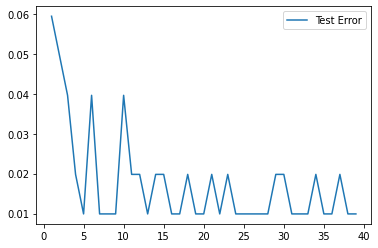

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, 40), test_error, marker='o', markersize=3, label='Test Error')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('Error Rate')
plt.title('Test Error vs. Number of Trees')
plt.legend()
plt.tight_layout()

Error stabilizes after roughly 10 trees on this dataset. The small sample size means the ensemble extracts most available signal quickly. Larger datasets typically continue improving across a wider range of tree counts, as demonstrated in Part 7 below.

---
## Part 7: Banknote Authentication

The [UCI Banknote Authentication dataset](https://archive.ics.uci.edu/ml/datasets/banknote+authentication) contains 1,372 records of genuine and counterfeit banknotes. Features are derived from wavelet transforms of scanned banknote images. The binary classification task (genuine vs. counterfeit) demonstrates GridSearchCV hyperparameter tuning and OOB scoring on a larger, more complex dataset.

| Feature | Description |
|---|---|
| variance | Variance of wavelet-transformed image |
| skewness | Skewness of wavelet-transformed image |
| curtosis | Kurtosis of wavelet-transformed image |
| entropy | Image entropy |
| Class | 0 = genuine, 1 = counterfeit |

In [ ]:
df_bank = pd.read_csv('data_banknote_authentication.csv')
print(f'Shape: {df_bank.shape}')
df_bank.head()

,Variance_Wavelet,Skewness_Wavelet,Curtosis_Wavelet,Image_Entropy,Class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [ ]:
print('Class distribution:')
print(df_bank['Class'].value_counts())

### Feature Pairplot by Class

Wavelet features show strong separation between genuine and counterfeit banknotes, particularly across variance and skewness. This confirms strong signal for the classifier.

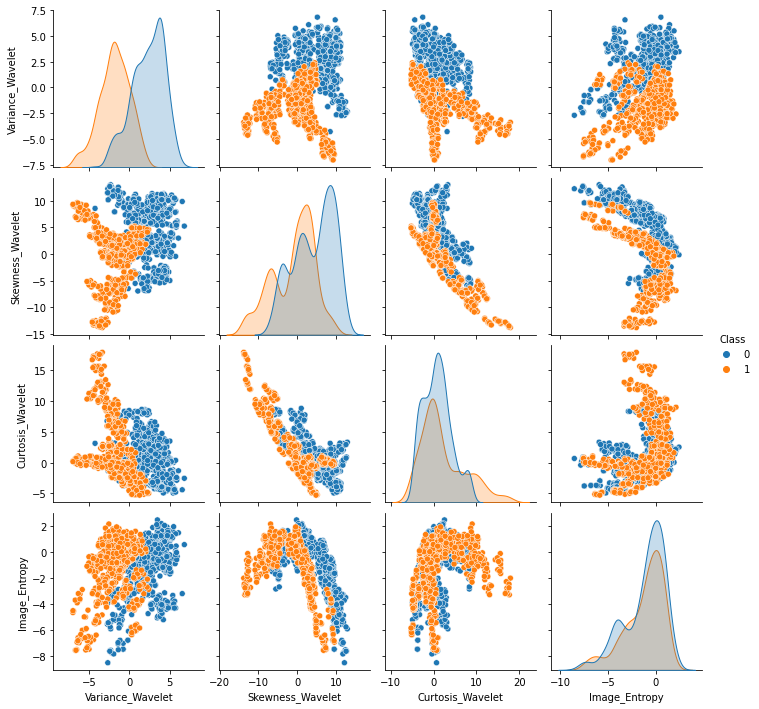

In [ ]:
sns.pairplot(df_bank, hue='Class')

### GridSearchCV Hyperparameter Tuning

Four key hyperparameters are swept via 5-fold cross-validation:

- **n_estimators:** number of trees in the ensemble
- **max_features:** number of features considered at each split
- **bootstrap:** whether to sample training data with replacement
- **oob_score:** whether to compute out-of-bag error (only valid when bootstrap=True)

In [ ]:
X_bank = df_bank.drop('Class', axis=1)
y_bank = df_bank['Class']

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_bank, y_bank, test_size=0.15, random_state=101
)

In [ ]:
n_estimators = [64, 100, 128, 200]
max_features = [2, 3, 4]
bootstrap    = [True, False]
oob_score    = [True, False]

param_grid = {
    'n_estimators': n_estimators,
    'max_features': max_features,
    'bootstrap':    bootstrap,
    'oob_score':    oob_score
}

In [ ]:
rfc  = RandomForestClassifier()
grid = GridSearchCV(rfc, param_grid, cv=5, n_jobs=-1)
grid.fit(X_train_b, y_train_b)

c:\users\marcial\anaconda_new\envs\ml_master\lib\site-packages\sklearn\model_selection\_validation.py:548: FitFailedWarning: Estimator fit failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\users\marcial\anaconda_new\envs\ml_master\lib\site-packages\sklearn\model_selection\_validation.py", line 531, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\users\marcial\anaconda_new\envs\ml_master\lib\site-packages\sklearn\ensemble\_forest.py", line 351, in fit
    raise ValueError("Out of bag estimation only available"
ValueError: Out of bag estimation only available if bootstrap=True

  warnings.warn("Estimator fit failed. The score on this train-test"
c:\users\marcial\anaconda_new\envs\ml_master\lib\site-packages\sklearn\model_selection\_validation.py:548: FitFailedWarning: Estimator fit failed. The score on this train-test partition for these parameters will be set to n

GridSearchCV(estimator=RandomForestClassifier(oob_score=True),
             param_grid={'bootstrap': [True, False], 'max_features': [2, 3, 4],
                         'n_estimators': [64, 100, 128, 200]})

In [ ]:
print('Best parameters:')
grid.best_params_

{'bootstrap': True, 'max_features': 2, 'n_estimators': 64}

In [ ]:
predictions = grid.predict(X_test_b)
print(classification_report(y_test_b, predictions))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99       124
           1       0.98      1.00      0.99        82

    accuracy                           0.99       206
   macro avg       0.99      0.99      0.99       206
weighted avg       0.99      0.99      0.99       206



In [ ]:
ConfusionMatrixDisplay(
    confusion_matrix(y_test_b, predictions)
).plot()
plt.title('Random Forest (GridSearchCV Best Estimator)')
plt.show()

### Out-of-Bag Score

When `bootstrap=True`, roughly one-third of training samples are excluded from each tree. These out-of-bag samples provide an unbiased generalization estimate without requiring a separate validation split.

In [ ]:
print(f'OOB score (best estimator): {grid.best_estimator_.oob_score_:.4f}')

0.9939965694682675

### Error Rate vs. Number of Trees (Banknote)

The tree count sweep is repeated on the larger banknote dataset. Both error rate and raw misclassification count are tracked to show where the ensemble stabilizes compared to the smaller penguin dataset above.

In [ ]:
errors = []
misclassifications = []

for n in range(1,64):
    rfc = RandomForestClassifier( n_estimators=n,bootstrap=True,max_features= 2)
    rfc.fit(X_train,y_train)
    preds = rfc.predict(X_test)
    err = 1 - accuracy_score(preds,y_test)
    n_missed = np.sum(preds != y_test) # watch the video to understand this line!!
    errors.append(err)
    misclassifications.append(n_missed)

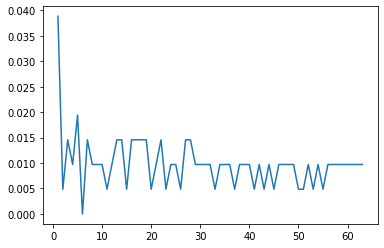

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, 64), errors)
axes[0].set_xlabel('Number of Trees')
axes[0].set_ylabel('Error Rate')
axes[0].set_title('Error Rate vs. Tree Count')

axes[1].plot(range(1, 64), misclassifications)
axes[1].set_xlabel('Number of Trees')
axes[1].set_ylabel('Misclassifications')
axes[1].set_title('Misclassifications vs. Tree Count')

plt.tight_layout()

On the banknote dataset, the ensemble continues improving beyond 10 trees before stabilizing around 30, reflecting the larger dataset size and higher feature count compared to penguins.

---

*End of project.*